In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
result = pd.read_csv("results.csv")
result

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn
0,MBON32,AVLP178,2,True,False,False,False,False,False,0.000002
1,MBON32,AVLP178,3,True,True,False,False,False,False,0.000006
2,MBON32,AVLP178,4,True,True,False,False,False,False,0.000016
3,MBON32,AVLP178,5,True,True,True,False,False,False,0.000024
4,MBON32,CB2309,2,True,True,False,False,False,False,0.000074
...,...,...,...,...,...,...,...,...,...,...
44795,MLt3,AVLP339,5,True,True,True,False,False,False,0.000594
44796,MLt3,CB2694,2,True,True,False,False,False,False,0.000009
44797,MLt3,CB2694,3,True,True,False,False,False,False,0.000074
44798,MLt3,CB2694,4,True,True,True,False,False,False,0.000146


In [3]:
# make longer: all columns starting with 'threshold'
result = result.melt(id_vars=['plen', 'effconn','pre','post'], value_vars=[col for col in result.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
result['threshold'] = result['threshold'].str.replace('threshold_','')
result['plen'] = result['plen'].astype(str)

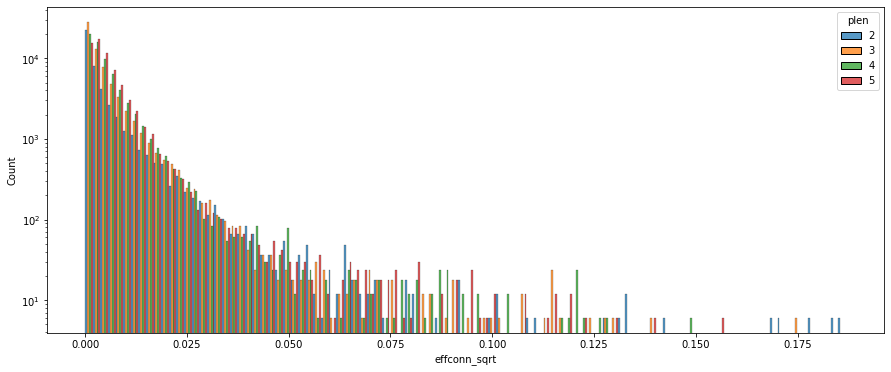

In [4]:
import numpy as np

plt.figure(figsize=(15,6))
sns.histplot(
    data=result[result.effconn.notna()]
         .assign(effconn_sqrt=lambda d: np.sqrt(d.effconn)),
    x="effconn_sqrt",
    hue="plen",
    bins=100,
    multiple="dodge"
)
plt.yscale("log")


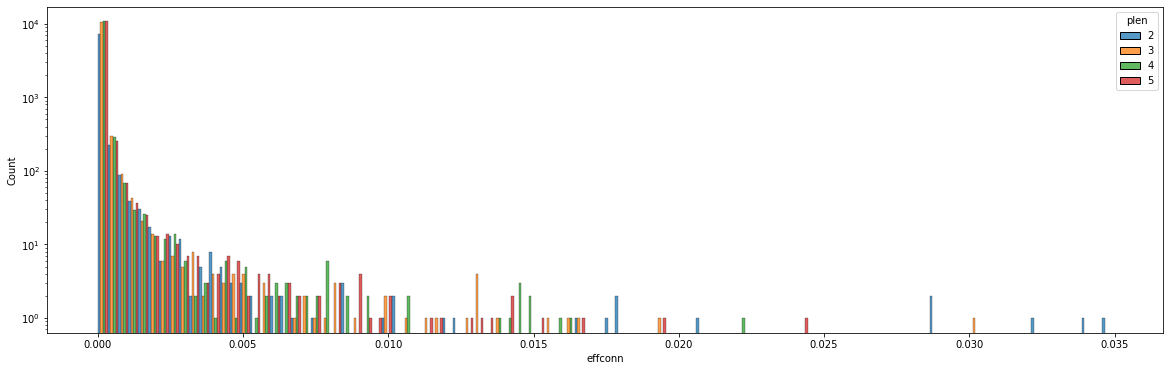

In [5]:
plt.figure(figsize=(20,6))
sns.histplot(data=result[result.effconn.notna()].drop_duplicates(['pre','post','plen']), x="effconn", hue='plen', bins = 100, 
multiple="dodge")
plt.yscale('log')


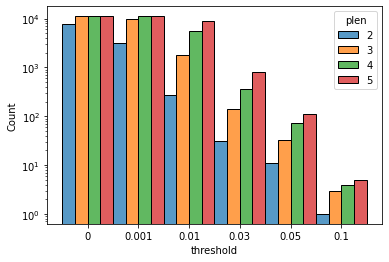

In [6]:
sns.histplot(result[result.value], x='threshold', hue='plen', multiple="dodge")
plt.yscale('log')

In [7]:
result[result.value][['plen','threshold']].value_counts()

plen  threshold
4     0            11200
5     0.001        11200
      0            11200
4     0.001        11189
3     0            11177
      0.001         9952
5     0.01          9042
2     0             7735
4     0.01          5534
2     0.001         3164
3     0.01          1789
5     0.03           793
4     0.03           369
2     0.01           279
3     0.03           144
5     0.05           112
4     0.05            74
3     0.05            32
2     0.03            31
      0.05            11
5     0.1              5
4     0.1              4
3     0.1              3
2     0.1              1
Name: count, dtype: int64